In [48]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [50]:
df=pd.read_csv('/content/nlp_dataset.csv')
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [51]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'did', 'down', "mustn't", 'or', 'ours', 'each', 'he', "he'd", 'himself', "mightn't", "shan't", 'other', "couldn't", 'for', 'herself', 'out', 'where', 'yourself', "we'd", 'had', 'the', 'o', 'were', 'off', 's', 'how', "i'm", 'there', "it's", 'here', 'in', 'll', 'too', 'their', 'against', 'don', 'm', 'an', "hadn't", 'be', 'haven', 'was', 'its', "shouldn't", 'that', 'myself', 'itself', 're', 'ma', "aren't", 'a', "he'll", 't', 'doing', 'such', 'up', 'i', "that'll", 'about', "doesn't", 'from', 'most', 'but', 'so', 'has', "they're", 'just', 'on', 'hasn', 've', 'again', 'over', 'couldn', 'while', "didn't", 'and', 'not', 'before', 'didn', 'now', 'won', 'few', "she'll", 'then', 'theirs', "you'll", 'those', 'do', "he's", "you've", 'what', 'below', "isn't", "haven't", 'once', 'at', "it'd", 'only', 'between', "should've", 'under', 'her', 'she', "won't", 'shouldn', 'hadn', 'hers', 'nor', 'this', 'if', 'as', 'mightn', 'than', 'wouldn', 'is', "we've", 'any', 'aren', "needn't", 'd', "she'd", 'our', 'f

In [52]:
def process_text(text):
  #Tokenization
  word_tokens=word_tokenize(text)

  #sTOPWORD REMOVAL
  filtered_tokens=[word for word in word_tokens if word.lower() not in stop_words]

  #LEMMATIZATION
  lemmatized_tokens=[lemmatizer.lemmatize(word) for word in filtered_tokens]

  return{
      "Original_Text":text,
      "Word_Tokens":word_tokens,
      "Filtered_Tokens":filtered_tokens,
      "Lemmatized_Tokens":lemmatized_tokens
  }

In [53]:
results=df['Text'].apply(process_text)

processed_df=pd.DataFrame(results.tolist())
processed_df.head()

,Original_Text,Word_Tokens,Filtered_Tokens,Lemmatized_Tokens
0,Natural Language Processing is a fascinating f...,"[Natural, Language, Processing, is, a, fascina...","[Natural, Language, Processing, fascinating, f...","[Natural, Language, Processing, fascinating, f..."
1,It bridges the gap between humans and machines...,"[It, bridges, the, gap, between, humans, and, ...","[bridges, gap, humans, machines, enabling, com...","[bridge, gap, human, machine, enabling, comput..."
2,NLP techniques are widely used in applications...,"[NLP, techniques, are, widely, used, in, appli...","[NLP, techniques, widely, used, applications, ...","[NLP, technique, widely, used, application, ch..."
3,Machine translation and speech recognition are...,"[Machine, translation, and, speech, recognitio...","[Machine, translation, speech, recognition, co...","[Machine, translation, speech, recognition, co..."
4,"Despite its advancements, NLP faces challenges...","[Despite, its, advancements, ,, NLP, faces, ch...","[Despite, advancements, ,, NLP, faces, challen...","[Despite, advancement, ,, NLP, face, challenge..."


In [54]:
processed_file_path='processed_nlp_dataset.csv'
processed_df.to_csv(processed_file_path,index=False)
print("Processed dataset saved to",processed_file_path)

Processed dataset saved to processed_nlp_dataset.csv


In [55]:
results

,Text
0,{'Original_Text': 'Natural Language Processing...
1,{'Original_Text': 'It bridges the gap between ...
2,{'Original_Text': 'NLP techniques are widely u...
3,{'Original_Text': 'Machine translation and spe...
4,"{'Original_Text': 'Despite its advancements, N..."
5,{'Original_Text': 'Continuous research and inn...
6,{'Original_Text': 'The potential of NLP is vas...


In [56]:
text_data={"Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology.",}

In [57]:
#Initialise CountVector
vectorizer=CountVectorizer()

#Fit and transform the text data
bow_matrix=vectorizer.fit_transform(text_data)


#Covert the matrix into dataframe
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())

#Display bag of words representation
print("Bag of Words Representation:")
bow_df


#convert to csv file
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of words saved as bag_of_words.csv")

Bag of Words Representation:

Bag of words saved as bag_of_words.csv


In [58]:
stemmer=PorterStemmer()

def lemmetize_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word) for word in tokens])

df['Lemmatized_Text']=df['Text'].apply(lemmetize_text)
df['Stemmed_Text']=df['Text'].apply(stem_text)

In [59]:
df

,Text,Lemmatized_Text,Stemmed_Text
0,Natural Language Processing is a fascinating f...,Natural Language Processing is a fascinating f...,natur languag process is a fascin field of art...
1,It bridges the gap between humans and machines...,It bridge the gap between human and machine by...,it bridg the gap between human and machin by e...
2,NLP techniques are widely used in applications...,NLP technique are widely used in application s...,nlp techniqu are wide use in applic such as ch...
3,Machine translation and speech recognition are...,Machine translation and speech recognition are...,machin translat and speech recognit are common...
4,"Despite its advancements, NLP faces challenges...","Despite it advancement , NLP face challenge in...","despit it advanc , nlp face challeng includ am..."
5,Continuous research and innovation are improvi...,Continuous research and innovation are improvi...,continu research and innov are improv nlp rapi...
6,"The potential of NLP is vast, making it essent...","The potential of NLP is vast , making it essen...","the potenti of nlp is vast , make it essenti i..."


In [60]:
output_path="lemmatization vs stemming.csv"
df.to_csv(output_path,index=False)
print("Lemmatization and stemming results saved to",output_path)

Lemmatization and stemming results saved to lemmatization vs stemming.csv


VISUALISATION


In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

data=pd.read_csv('/content/nlp_dataset.csv')

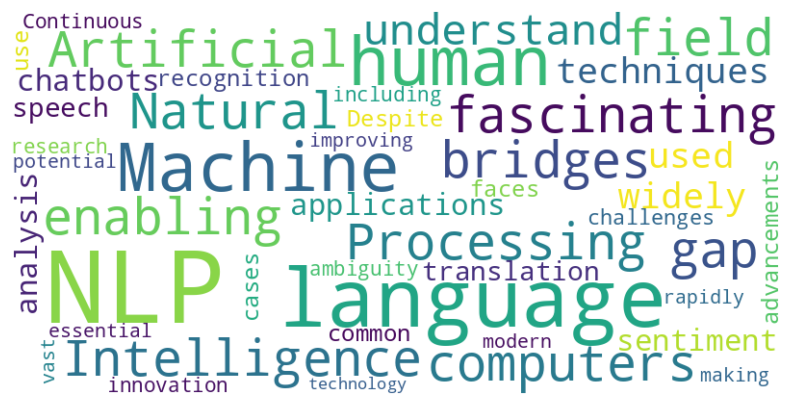

In [62]:
text_data=" ".join(data['Text'])

#Word Cloud generation
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()